In [500]:
from networkx.readwrite import json_graph
import json
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
from collections import Counter
import random

In [501]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreasstampedalgaard/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [502]:
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G = json_graph.node_link_graph(data)

In [503]:
rows = []

for u, v, attrs in G.edges(data=True):
    text = attrs.get("TXT", attrs.get("text", ""))
    vote = attrs.get("VOT", attrs.get("vote", None))
    
    # keep only entries that actually have text
    if text is not None:
        text = str(text).strip()
    else:
        text = ""
    
    if text:
        rows.append({
            "source": u,
            "target": v,
            "vote": vote,
            "text": text
        })

print("Number of rows with text:", len(rows))
print("Example row:")
print(rows[0] if rows else "No rows found")

Number of rows with text: 191085
Example row:
{'source': 'Steel1943', 'target': 'BDD', 'vote': 1, 'text': "'''Support''' as co-nom."}


In [504]:
# Step 4: map vote values to readable labels
vote_map = {
    1: "positive",
    0: "neutral",
    -1: "negative"
}

for row in rows:
    row["label"] = vote_map.get(row["vote"], "unknown")

label_counts = Counter(row["label"] for row in rows)
print(label_counts)

Counter({'positive': 138715, 'negative': 40435, 'neutral': 11935})


In [505]:
custom_stopwords = {
    "support", "oppose", "neutral",
    "wikipedia", "wiki", "user", "editor",
    "admin", "candidate", "rfa",
    "vote", "voted", "voting",
    "page", "article",
    "would", "could", "should", "also",
    "one", "two", "well", "like", "think",
    "see", "really", "much", "many",
    "per", "however", "since",
    "make", "made",
    "nbsp", "mdash", "ndash", "nom"
}

all_stopwords = stop_words.union(custom_stopwords)

In [506]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"\[\[.*?\]\]", " ", text)   # wiki links
    text = re.sub(r"<.*?>", " ", text)         # html-like tags
    text = re.sub(r"'{2,}", " ", text)         # wiki bold/italic
    text = re.sub(r"http\S+", " ", text)       # urls
    text = re.sub(r"[^a-z\s]", " ", text)      # keep letters only
    
    tokens = text.split()
    
    tokens = [
        w for w in tokens
        if w not in all_stopwords and len(w) > 2
    ]
    
    return tokens

In [507]:
for row in rows:
    row["tokens"] = clean_text(row["text"])

In [508]:
positive_docs = []
negative_docs = []
neutral_docs = []

for row in rows:
    text = " ".join(row["tokens"])  # convert tokens back to string
    
    if row["label"] == "positive":
        positive_docs.append(text)
    elif row["label"] == "negative":
        negative_docs.append(text)
    elif row["label"] == "neutral":
        neutral_docs.append(text)

print(len(positive_docs), len(negative_docs), len(neutral_docs))

138715 40435 11935


In [509]:
all_docs = positive_docs + negative_docs + neutral_docs

df = Counter()
for doc in all_docs:
    for w in set(doc.split()):
        df[w] += 1

N = len(all_docs)

In [510]:
def compute_tfidf_scores(docs, df, N):
    tfidf = defaultdict(float)
    
    for doc in docs:
        words = doc.split()
        counts = Counter(words)
        total = len(words)
        
        for w, c in counts.items():
            tf = c / total
            idf = math.log(N / (1 + df[w]))
            tfidf[w] += tf * idf
    
    for w in tfidf:
        tfidf[w] /= len(docs)
    
    return tfidf

In [511]:
tfidf_pos = compute_tfidf_scores(positive_docs, df, N)
tfidf_neg = compute_tfidf_scores(negative_docs, df, N)
tfidf_neu = compute_tfidf_scores(neutral_docs, df, N)

In [512]:
def top_words(tfidf_dict, n=20):
    return sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:n]

In [513]:
def top_n_dict(tfidf_dict, n=80):
    return dict(sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:n])

In [514]:
def make_wordcloud(tfidf_dict, title, max_words=80):
    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=max_words
    ).generate_from_frequencies(tfidf_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

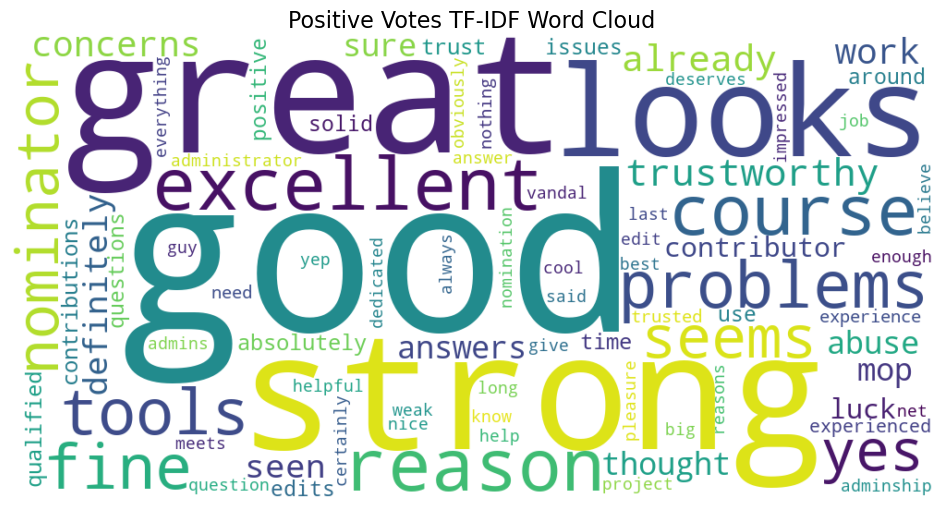

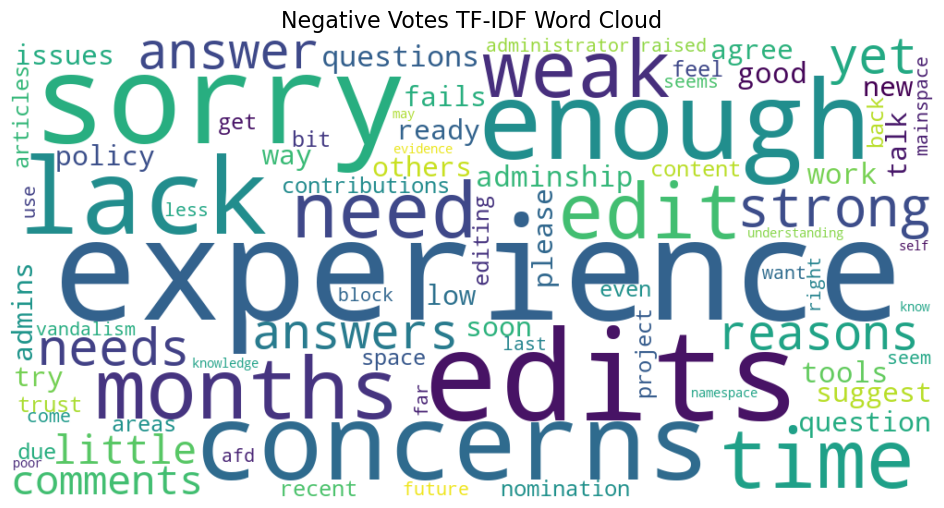

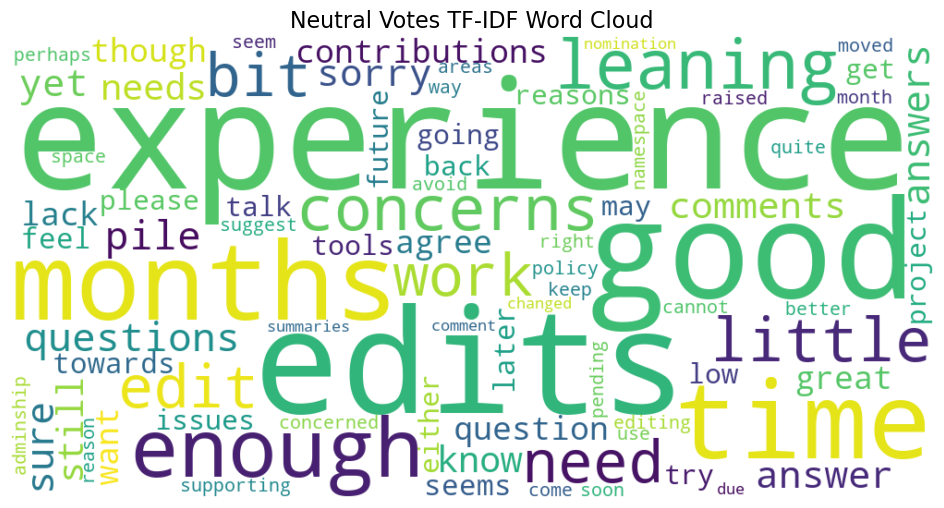

In [515]:
make_wordcloud(top_n_dict(tfidf_pos, 80), "Positive Votes TF-IDF Word Cloud")
make_wordcloud(top_n_dict(tfidf_neg, 80), "Negative Votes TF-IDF Word Cloud")
make_wordcloud(top_n_dict(tfidf_neu, 80), "Neutral Votes TF-IDF Word Cloud")